In [17]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

In [18]:
sentiment_datasets_processed_path = r'..\data\processed\sentiment_processed.csv'
sentiment_datasets_processed_df = pd.read_csv(sentiment_datasets_processed_path)

sentiment_datasets_processed_df = sentiment_datasets_processed_df.dropna()

## Splitting data

In [19]:
X = sentiment_datasets_processed_df['text']
Y = sentiment_datasets_processed_df['label']

x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state= 0, stratify=Y)

## Encoder label

In [20]:
label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(y_train)
y_test =label_encoder.transform(y_test)

## Vectorlization

In [21]:
tfidf = TfidfVectorizer(max_features= 10000)

x_train_tfidf = tfidf.fit_transform(x_train)
x_test_tfidf = tfidf.transform(x_test)

## Select Model/ Trainning

### LogisticRegression model

In [22]:
model_LR = LogisticRegression(
    max_iter= 1000,
    C= 0.5,
    penalty='l2',
    solver='lbfgs',
    class_weight='balanced'
)
model_LR.fit(x_train_tfidf, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,0.5
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


### SVM model

In [23]:
from sklearn.svm import LinearSVC
model_SVM = LinearSVC(
    C= 0.5,
    max_iter = 1000,
    class_weight='balanced',
)

model_SVM.fit(x_train_tfidf, y_train)

,penalty,'l2'
,loss,'squared_hinge'
,dual,'auto'
,tol,0.0001
,C,0.5
,multi_class,'ovr'
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,verbose,0
,random_state,None


## Evaluation

In [24]:
y_pred_lr = model_LR.predict(x_test_tfidf)

print(f"accuracy_score: {accuracy_score(y_test, y_pred_lr)}")

print(f"classification_report:\n {classification_report(y_test, y_pred_lr, target_names= label_encoder.classes_)}")

accuracy_score: 0.965857223829838
classification_report:
               precision    recall  f1-score   support

    negative       0.97      0.97      0.97     47772
     neutral       0.95      0.96      0.96     38710
    positive       0.97      0.97      0.97     47602

    accuracy                           0.97    134084
   macro avg       0.97      0.97      0.97    134084
weighted avg       0.97      0.97      0.97    134084



In [25]:
y_pred_svm = model_SVM.predict(x_test_tfidf)
print(f'accuracy score: {accuracy_score(y_test,y_pred_svm)}')
print(f'classification_report: \n{classification_report(y_test, y_pred_svm, target_names= label_encoder.classes_)}')

accuracy score: 0.9668416813340891
classification_report: 
              precision    recall  f1-score   support

    negative       0.97      0.97      0.97     47772
     neutral       0.96      0.96      0.96     38710
    positive       0.97      0.97      0.97     47602

    accuracy                           0.97    134084
   macro avg       0.97      0.97      0.97    134084
weighted avg       0.97      0.97      0.97    134084



In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Mapping số -> nhãn
label_mapping = {0: "Negative", 1: "Neutral", 2: "Positive"}
labels = ["Negative", "Neutral", "Positive"]

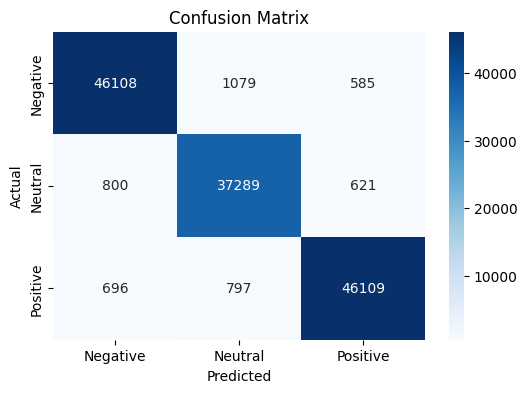

In [27]:
# Tạo confusion matrix
cm = confusion_matrix(y_test, y_pred_lr, labels=[0,1,2])

# Vẽ heatmap
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

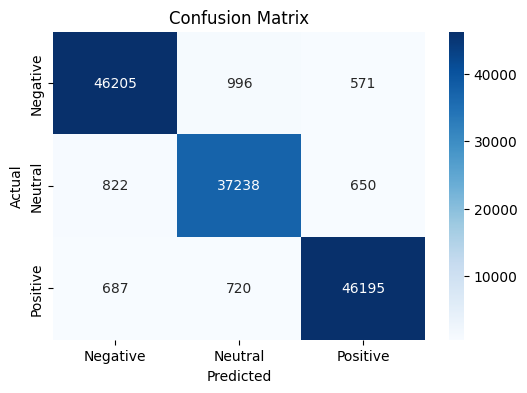

In [28]:
# Tạo confusion matrix
cm = confusion_matrix(y_test, y_pred_svm, labels=[0,1,2])

# Vẽ heatmap
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


## Save model_trained

In [29]:
import joblib

In [30]:
joblib.dump ((tfidf, label_encoder, model_LR), r"..\models\sentiment_pipeline_lr.pkl")

['..\\models\\sentiment_pipeline_lr.pkl']

In [31]:
joblib.dump ((tfidf, label_encoder, model_SVM), r"..\models\sentiment_pipeline_svm.pkl")

['..\\models\\sentiment_pipeline_svm.pkl']

In [32]:
# from sklearn.model_selection import GridSearchCV
# from sklearn.svm import LinearSVC

# params =  {'C' : [0.1, 0.5, 1, 2, 5], 'max_iter' :[1000, 5000, 10000]}
# gird = GridSearchCV(
#     LinearSVC(class_weight='balanced'),
#     param_grid= params,
#     cv= 5,
#     scoring='accuracy',
#     n_jobs= -1 
# )

# gird.fit(x_train_tfidf, y_train)

# print("Best C:", gird.best_params_)
# print("Best CV Score:", gird.best_score_)
